In [1]:
#import require python classes and packages
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from keras.models import Sequential, load_model
from keras.layers import Dense
from keras.layers import LSTM #class for LSTM training
import os
from keras.layers import Dropout
from keras.callbacks import ModelCheckpoint
from keras.layers import Bidirectional,GRU
from Attention import attention #importing attention layer
from keras.layers import SimpleRNN
from sklearn.metrics import mean_absolute_error
from math import sqrt

Using TensorFlow backend.
c:\users\user\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\user\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\user\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16, 1

In [2]:
#read and display dataset values
dataset = pd.read_csv("Dataset/Water_Quality_Testing.csv")
dataset.fillna(0, inplace = True)#remove missing values
dataset

,Sample ID,pH,Temperature (°C),Turbidity (NTU),Dissolved Oxygen (mg/L),Conductivity (µS/cm)
0,1,7.25,23.1,4.5,7.8,342
1,2,7.11,22.3,5.1,6.2,335
2,3,7.03,21.5,3.9,8.3,356
3,4,7.38,22.9,3.2,9.5,327
4,5,7.45,20.7,3.8,8.1,352
...,...,...,...,...,...,...
495,496,7.01,20.8,4.6,7.1,327
496,497,7.31,22.5,3.8,9.4,361
497,498,7.02,21.2,4.7,7.5,334
498,499,7.25,23.0,3.9,8.7,359


In [3]:
def plotGraph(data, name):
    plt.plot(data, color = 'green', label = name)
    plt.title(name+' Values Graph')
    plt.xlabel(name)
    plt.ylabel('Values')
    plt.legend()
    plt.show()

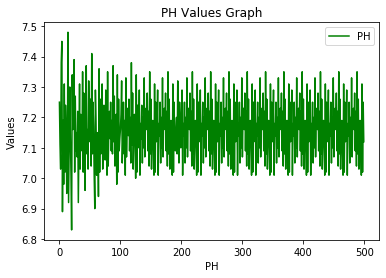

In [4]:
plotGraph(dataset['pH'], "PH")

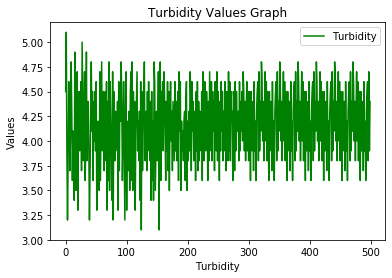

In [5]:
plotGraph(dataset['Turbidity (NTU)'], "Turbidity")

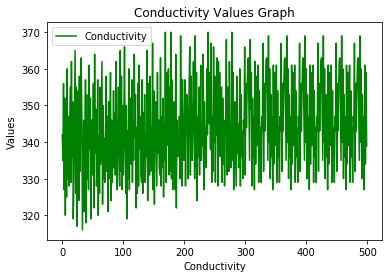

In [6]:
plotGraph(dataset['Conductivity (µS/cm)'], "Conductivity")

c:\users\user\appdata\local\programs\python\python37\lib\site-packages\joblib\externals\loky\backend\context.py:152: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  "following reason:\n" + str(exception) + "\n"
  File "c:\users\user\appdata\local\programs\python\python37\lib\site-packages\joblib\externals\loky\backend\context.py", line 229, in _count_physical_cores
    capture_output=True)
  File "c:\users\user\appdata\local\programs\python\python37\lib\subprocess.py", line 472, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\users\user\appdata\local\programs\python\python37\lib\subprocess.py", line 775, in __init__
    restore_signals, start_new_session)
  File "c:\users\user\appdata\local\programs\python\python37\lib\subprocess.py"

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000198 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 143
[LightGBM] [Info] Number of data points in the train set: 500, number of used features: 4
[LightGBM] [Info] Start training from score 8.382200
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

Temperature having less importance value so it will be removed out
               Features  Importances
1      Temperature (°C)    18.478261
0                    pH    23.913043
2       Turbidity (NTU)    28.260870
3  Conductivity (µS/cm)    29.347826


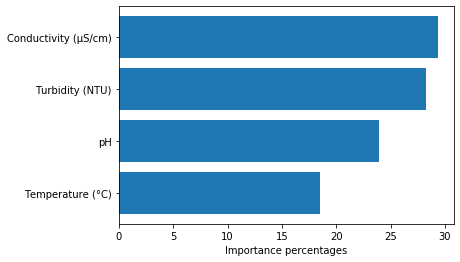

In [7]:
#now apply LIGHTGBM algorithm to selecte relevant features
Y = dataset.values[:,1:2]
Y = dataset['Dissolved Oxygen (mg/L)'].ravel()
Y1 = dataset.values[:,4:5]
dataset.drop(['Sample ID','Dissolved Oxygen (mg/L)'], axis = 1,inplace=True)
columns = dataset.columns.tolist()
X = dataset.values
#now create and apply LIGHtGBM object on water dataset
clf = lgb.LGBMRegressor(num_leaves=100,learning_rate=0.2,boosting_type='gbdt',n_estimators=5)
clf.fit(X, Y)
#calculate importance
feature_importances = (clf.feature_importances_ / sum(clf.feature_importances_)) * 100
results = pd.DataFrame({'Features': columns, 'Importances': feature_importances})
results.sort_values(by='Importances', inplace=True)
print()
print("Temperature having less importance value so it will be removed out")
print(results)
columns = results['Features'].tolist()
importance = results['Importances'].tolist()
for i in range(len(columns)):
    if importance[i] < 20:
        dataset.drop([columns[i]], axis = 1,inplace=True)
ax = plt.barh(results['Features'], results['Importances'])
plt.xlabel('Importance percentages')
plt.show()


In [8]:
#now preprocess dataset based on selected columns using LIGHTGBM and then split dataset into train and test
X = dataset.values
sc = MinMaxScaler(feature_range = (0, 1))
sc1 = MinMaxScaler(feature_range = (0, 1))
X = sc.fit_transform(X)
Y = sc1.fit_transform(Y1)
X = np.reshape(X, (X.shape[0], X.shape[1], 1))
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Total records found in dataset = "+str(X.shape[0]))
print("Total features found in dataset after LIGHTGBM selection : "+str(X.shape[1]))
print("80% dataset for training : "+str(X_train.shape[0]))
print("20% dataset for testing  : "+str(X_test.shape[0]))

Total records found in dataset = 500
Total features found in dataset after LIGHTGBM selection : 3
80% dataset for training : 400
20% dataset for testing  : 100


In [9]:
#now define global variables for mse and other metrics
mse = []
rmse = []
mae = []


In [10]:
#function to calculate MSE and other metrics
def calculateMetrics(algorithm, predict, test_labels):
    predict = sc1.inverse_transform(predict)
    test_label = sc1.inverse_transform(test_labels)
    predict = predict.ravel()
    test_label = test_label.ravel()
    mse_value = mean_squared_error(test_label, predict)
    rmse_value = sqrt(mse_value)
    mae_value = mean_absolute_error(test_label, predict)
    mse.append(mse_value)
    rmse.append(rmse_value)
    mae.append(mae_value)
    print(algorithm+" MSE  : "+str(mse_value))
    print(algorithm+" RMSE : "+str(rmse_value))
    print(algorithm+" MAE  : "+str(mae_value))
    plt.plot(test_label, color = 'red', label = 'Original Dissolved Oxygen')
    plt.plot(predict, color = 'green', label = 'Predicted Dissolved Oxygen')
    plt.title(algorithm+' Dissolved Oxygen Prediction')
    plt.xlabel('Test Data')
    plt.ylabel('Predicted Dissolved Oxygen')
    plt.legend()
    plt.show()


LightGBM-LSTM MSE  : 0.2240669957306242
LightGBM-LSTM RMSE : 0.47335715451509147
LightGBM-LSTM MAE  : 0.3459676418304442


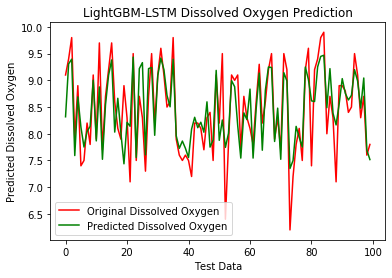

In [11]:
#Now train LSTM with LightGBM selected Features
lstm = Sequential()
lstm.add(LSTM(units = 50, return_sequences = True, input_shape = (X_train.shape[1], X_train.shape[2])))
lstm.add(Dropout(0.2))
lstm.add(LSTM(units = 50, return_sequences = True))
lstm.add(Dropout(0.2))
lstm.add(LSTM(units = 50, return_sequences = True))
lstm.add(Dropout(0.2))
lstm.add(LSTM(units = 50))
lstm.add(Dropout(0.2))
lstm.add(Dense(units = 1))
lstm.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists('model/lstm_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm_weights.hdf5', verbose = 1, save_best_only = True)
    lstm.fit(X_train, y_train, epochs = 250, batch_size = 4, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
else:
    lstm = load_model('model/lstm_weights.hdf5')
predict = lstm.predict(X_test)
calculateMetrics("LightGBM-LSTM", predict, y_test)

LightGBM-GRU MSE  : 0.2282927704043715
LightGBM-GRU RMSE : 0.4777999271707474
LightGBM-GRU MAE  : 0.35497156810760494


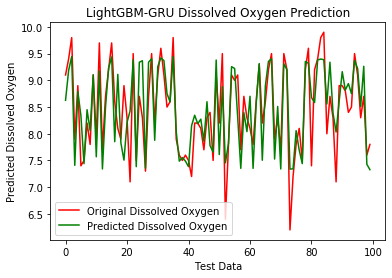

In [12]:
#now train GRU with LightGBM Selected Features
gru = Sequential()
gru.add(GRU(units = 50, return_sequences = True, input_shape = (X_train.shape[1], X_train.shape[2])))
gru.add(Dropout(0.2))
gru.add(GRU(units = 50, return_sequences = True))
gru.add(Dropout(0.2))
gru.add(GRU(units = 50, return_sequences = True))
gru.add(Dropout(0.2))
gru.add(GRU(units = 50))
gru.add(Dropout(0.2))
gru.add(Dense(units = 1))
gru.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists('model/gru_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/gru_weights.hdf5', verbose = 1, save_best_only = True)
    gru.fit(X_train, y_train, epochs = 250, batch_size = 4, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
else:
    gru = load_model('model/gru_weights.hdf5', custom_objects={'attention': attention})
predict = gru.predict(X_test)
calculateMetrics("LightGBM-GRU", predict, y_test)

Propose LightGBM-BISRU-Attention MSE  : 0.20123957106935095
Propose LightGBM-BISRU-Attention RMSE : 0.44859733734090634
Propose LightGBM-BISRU-Attention MAE  : 0.3125025243759155


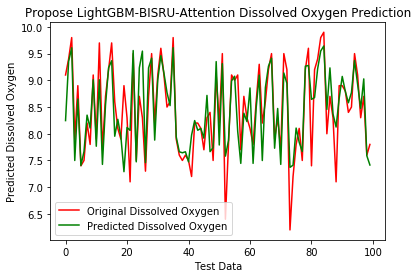

In [13]:
#now train BISRU with Attention using LightGBM features
bisru = Sequential()
bisru.add(Bidirectional(SimpleRNN(units = 50, input_shape = (X_train.shape[1], X_train.shape[2]), return_sequences=True)))
bisru.add(Dropout(0.4))
bisru.add(Bidirectional(SimpleRNN(units = 50, return_sequences = True)))
bisru.add(Dropout(0.4))
bisru.add(Bidirectional(SimpleRNN(units = 50, return_sequences = True)))
bisru.add(Dropout(0.4))
bisru.add(attention(return_sequences=True,name='attention')) # define Attention layer
bisru.add(Bidirectional(SimpleRNN(units = 50)))
bisru.add(Dropout(0.4))
bisru.add(Dense(units = 1))
bisru.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists('model/bisru_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/bisru_weights.hdf5', verbose = 1, save_best_only = True)
    bisru.fit(X_train, y_train, epochs = 250, batch_size = 4, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
else:
    bisru = load_model('model/bisru_weights.hdf5')
predict = bisru.predict(X_test)
calculateMetrics("Propose LightGBM-BISRU-Attention", predict, y_test)

Extension Ensemble LightGBM-BISRU-Attention MSE  : 0.1941879293409357
Extension Ensemble LightGBM-BISRU-Attention RMSE : 0.44066759506564096
Extension Ensemble LightGBM-BISRU-Attention MAE  : 0.30817756175994876


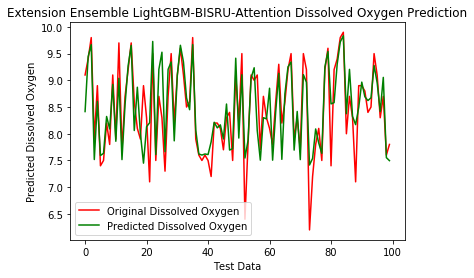

In [14]:
#now train extension ensemble model by combining all 3 differenet algorithms as a single model
extension = Sequential()
#adding BILSTM 
extension.add(Bidirectional(LSTM(units = 50, input_shape = (X_train.shape[1], X_train.shape[2]), return_sequences=True)))
extension.add(Dropout(0.5))
#adding BIGRU as ensemble
extension.add(Bidirectional(GRU(units = 50, return_sequences = True)))
extension.add(Dropout(0.5))
#adding BISRU as ensemble
extension.add(Bidirectional(SimpleRNN(units = 50, return_sequences = True)))
extension.add(Dropout(0.5))
extension.add(attention(return_sequences=True,name='attention')) # define Attention layer
extension.add(Bidirectional(SimpleRNN(units = 50)))
extension.add(Dropout(0.5))
extension.add(Dense(units = 1))
extension.compile(optimizer = 'adam', loss = 'mean_squared_error')
if os.path.exists('model/extension_weights.hdf5') == False:
    model_check_point = ModelCheckpoint(filepath='model/extension_weights.hdf5', verbose = 1, save_best_only = True)
    extension.fit(X, Y, epochs = 250, batch_size = 4, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
else:
    extension = load_model('model/extension_weights.hdf5', custom_objects={'attention': attention})
predict = extension.predict(X_test)
calculateMetrics("Extension Ensemble LightGBM-BISRU-Attention", predict, y_test)

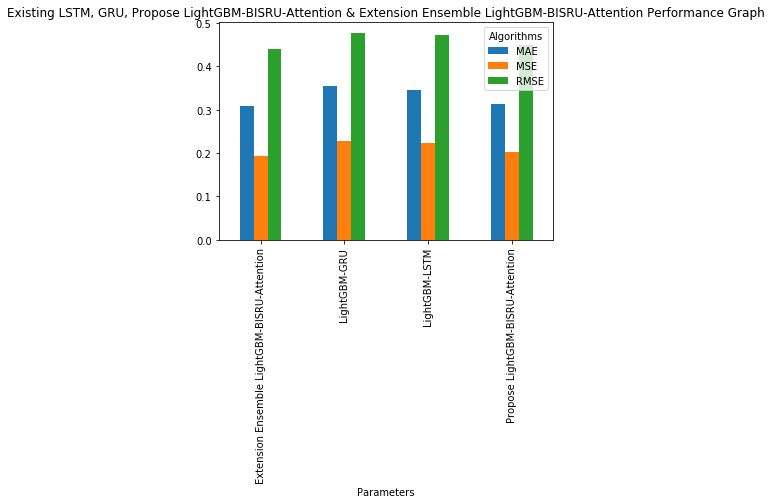

In [15]:
df = pd.DataFrame([['LightGBM-LSTM','MSE',mse[0]],['LightGBM-LSTM','RMSE',rmse[0]],['LightGBM-LSTM','MAE',mae[0]],
                   ['LightGBM-GRU','MSE',mse[1]],['LightGBM-GRU','RMSE',rmse[1]],['LightGBM-GRU','MAE',mae[1]],
                   ['Propose LightGBM-BISRU-Attention','MSE',mse[2]],['Propose LightGBM-BISRU-Attention','RMSE',rmse[2]],['Propose LightGBM-BISRU-Attention','MAE',mae[2]],
                   ['Extension Ensemble LightGBM-BISRU-Attention','MSE',mse[3]],['Extension Ensemble LightGBM-BISRU-Attention','RMSE',rmse[3]],['Extension Ensemble LightGBM-BISRU-Attention','MAE',mae[3]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar')
plt.title("Existing LSTM, GRU, Propose LightGBM-BISRU-Attention & Extension Ensemble LightGBM-BISRU-Attention Performance Graph")
plt.show()

In [16]:
#showing all algorithms with scenario A and B performance values
columns = ["Algorithm Name","MSE","RMSE","MAE"]
values = []
algorithm_names = ["Existing LSTM","Existing GRU", "Propose LightGBM-BISRU-Attention","Extension Ensemble LightGBM-BISRU-Attention"]
for i in range(len(algorithm_names)):
    values.append([algorithm_names[i],mse[i],rmse[i],mae[i]])
    
temp = pd.DataFrame(values,columns=columns)
temp

,Algorithm Name,MSE,RMSE,MAE
0,Existing LSTM,0.224067,0.473357,0.345968
1,Existing GRU,0.228293,0.477800,0.354972
2,Propose LightGBM-BISRU-Attention,0.201240,0.448597,0.312503
3,Extension Ensemble LightGBM-BISRU-Attention,0.194188,0.440668,0.308178


In [17]:
#perform dissolved oxygen prediction on test data using extension object
testData = pd.read_csv("Dataset/testData.csv")
testData = testData.values
test = sc.transform(testData)
test = np.reshape(test, (test.shape[0], test.shape[1], 1))
predict = extension.predict(test)#predict with extension object
predict = sc1.inverse_transform(predict)
predict = predict.ravel()
for i in range(len(testData)):
    print("Test Data : "+str(testData[i])+" =====> Predicted Oxygen : "+str(predict[i])+"\n")

Test Data : [  7.12   4.1  343.  ] =====> Predicted Oxygen : 8.310683

Test Data : [  7.16   3.9  339.  ] =====> Predicted Oxygen : 8.309686

Test Data : [  7.29   4.5  364.  ] =====> Predicted Oxygen : 9.470409

Test Data : [  7.01   4.2  327.  ] =====> Predicted Oxygen : 7.5044622

Test Data : [ 23.2   9.1 351. ] =====> Predicted Oxygen : 8.766305

Test Data : [  7.35   3.7  369.  ] =====> Predicted Oxygen : 9.705333

Test Data : [  7.08   4.6  340.  ] =====> Predicted Oxygen : 7.9193616

Test Data : [  7.26   3.9  360.  ] =====> Predicted Oxygen : 9.252319

Test Data : [  7.03   4.2  330.  ] =====> Predicted Oxygen : 7.621204

